# Random forest classification of footballers

In [8]:
import pandas as pd

df = pd.read_csv('../../data/footballers_big_dataset.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Spelare           100 non-null    object
 1   Position          100 non-null    object
 2   Mål               100 non-null    int64 
 3   Assist            100 non-null    int64 
 4   Passningsprocent  100 non-null    int64 
 5   Tacklingar        100 non-null    int64 
 6   Interceptioner    100 non-null    int64 
 7   Skott             100 non-null    int64 
 8   Luftdueller       100 non-null    int64 
 9   Dribblingar       100 non-null    int64 
 10  Räddningar        100 non-null    int64 
dtypes: int64(9), object(2)
memory usage: 8.7+ KB


In [25]:
# What's a feature and what's a target?
# The reason I type axis="columns" is because that tells pandas to drop a COLUMN and NOT a ROW
X, y = df.drop(["Position", "Spelare"], axis="columns"), df["Position"]



In [1]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

NameError: name 'X' is not defined

In [27]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
footballer_pos = RandomForestClassifier(
    n_estimators=100, # number of trees in the model
    random_state=42, # for reusability (gives the same output every time)
    n_jobs=-1 # Use all CPU cores
)

footballer_pos.fit(X_train, y_train)

y_pred = footballer_pos.predict(X_test)

(33,)

In [32]:
# Typing out name and predicted position

test_players = df.loc[y_test.index, "Spelare"]

for player, prediction in zip(test_players, y_pred):
    print(f"Spelare: {player}, position: {prediction}")

Spelare: Fabien Barthez, position: Målvakt
Spelare: Kyle Walker, position: Försvarare
Spelare: Manuel Neuer, position: Målvakt
Spelare: Matthijs de Ligt, position: Försvarare
Spelare: Kalidou Koulibaly, position: Mittfältare
Spelare: Martin Ødegaard, position: Mittfältare
Spelare: Toni Kroos, position: Mittfältare
Spelare: Petr Čech, position: Målvakt
Spelare: Mohamed Salah, position: Anfallare
Spelare: Lionel Messi, position: Anfallare
Spelare: Gabriel Jesus, position: Anfallare
Spelare: Thiago Alcântara, position: Mittfältare
Spelare: Ederson Moraes, position: Målvakt
Spelare: Phil Foden, position: Mittfältare
Spelare: Ronaldo Nazário, position: Anfallare
Spelare: Erling Haaland, position: Anfallare
Spelare: David de Gea, position: Målvakt
Spelare: Marc-André ter Stegen, position: Målvakt
Spelare: Son Heung-min, position: Anfallare
Spelare: Frankie de Jong, position: Mittfältare
Spelare: João Cancelo, position: Försvarare
Spelare: Samir Handanović, position: Målvakt
Spelare: Casemiro

In [ ]:
# We evaluate our model
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Our accuracy was: {accuracy*100:.2f}%")



Our accuracy was: 96.97%


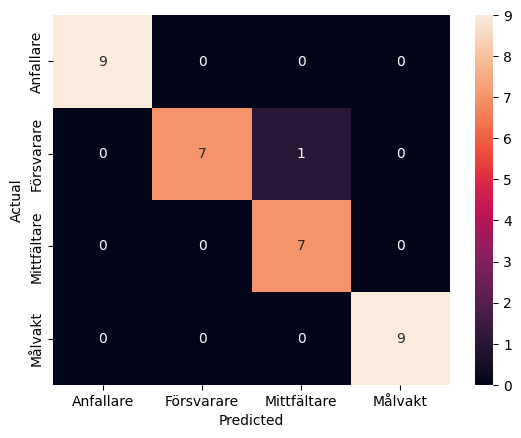

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=footballer_pos.classes_)
sns.heatmap(cm, annot=True, fmt="d", 
xticklabels=footballer_pos.classes_, yticklabels=footballer_pos.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()